In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/sharmaroshan/Clustering-of-Mall-Customers/master/Mall_Customers.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 200
Columns: 5


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
print("===== DATASET INFORMATION =====")
print()

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

===== DATASET INFORMATION =====

Dataset Shape:
(200, 5)

Column Names:
['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Data Types:
CustomerID                 int64
Genre                     object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Missing Values:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate Rows:
0


In [ ]:
print("===== FIRST 10 ROWS =====")
display(df.head(10))

print("\n===== LAST 10 ROWS =====")
display(df.tail(10))

print("\n===== STATISTICAL SUMMARY =====")
display(df.describe())

===== FIRST 10 ROWS =====


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72



===== LAST 10 ROWS =====


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
190,191,Female,34,103,23
191,192,Female,32,103,69
192,193,Male,33,113,8
193,194,Female,38,113,91
194,195,Female,47,120,16
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83



===== STATISTICAL SUMMARY =====


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
# ============================================
# STEP 5: DATA CLEANING & VALIDATION
# ============================================

# Create a working copy
df_clean = df.copy()

# 1. Remove completely duplicated records
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)

print("Duplicate rows removed:", before - after)

# 2. Check missing values
missing_values = df_clean.isnull().sum()

print("\nMissing values by column:")
print(missing_values)

# 3. Validate numeric columns
numeric_columns = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

print("\nNumeric column validation:")
print(df_clean[numeric_columns].dtypes)

# 4. Validate logical ranges
print("\nRange validation:")

print(
    "Age range:",
    df_clean["Age"].min(),
    "to",
    df_clean["Age"].max()
)

print(
    "Annual Income range:",
    df_clean["Annual Income (k$)"].min(),
    "to",
    df_clean["Annual Income (k$)"].max()
)

print(
    "Spending Score range:",
    df_clean["Spending Score (1-100)"].min(),
    "to",
    df_clean["Spending Score (1-100)"].max()
)

# 5. Final dataset shape
print("\nFinal cleaned dataset shape:", df_clean.shape)

Duplicate rows removed: 0

Missing values by column:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Numeric column validation:
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

Range validation:
Age range: 18 to 70
Annual Income range: 15 to 137
Spending Score range: 1 to 99

Final cleaned dataset shape: (200, 5)


In [ ]:
# ============================================
# STEP 6.1: EXPLORATORY DATA ANALYSIS
# Customer Distribution by Gender
# ============================================

import matplotlib.pyplot as plt

gender_counts = df_clean["Gender"].value_counts()

plt.figure(figsize=(7, 5))
gender_counts.plot(kind="bar")

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

KeyError: 'Gender'

In [ ]:
print("Exact column names:")
for i, column in enumerate(df_clean.columns):
    print(i, repr(column))

Exact column names:
0 'CustomerID'
1 'Genre'
2 'Age'
3 'Annual Income (k$)'
4 'Spending Score (1-100)'


In [ ]:
import matplotlib.pyplot as plt

# Automatically find the gender column
gender_column = [col for col in df_clean.columns if "gender" in col.lower()][0]

print("Gender column found:", gender_column)

gender_counts = df_clean[gender_column].value_counts()

plt.figure(figsize=(7, 5))
gender_counts.plot(kind="bar")

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

IndexError: list index out of range

In [ ]:
print(df_clean.columns.tolist())


['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


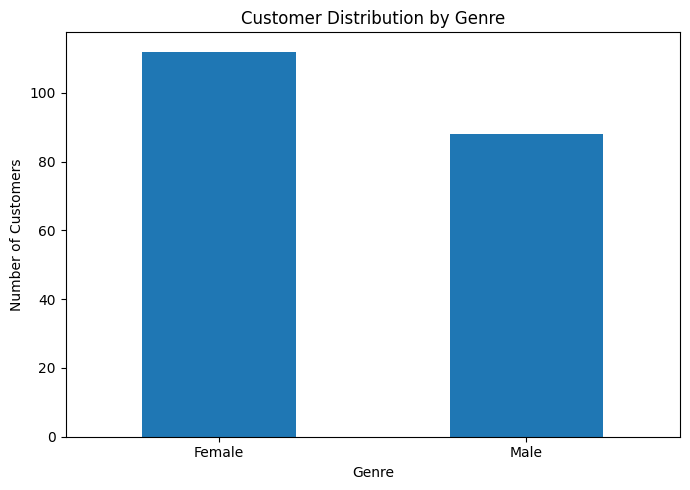

In [ ]:
# ============================================
# STEP 6.1: CUSTOMER DISTRIBUTION BY GENRE
# ============================================

import matplotlib.pyplot as plt

genre_counts = df_clean["Genre"].value_counts()

plt.figure(figsize=(7, 5))
genre_counts.plot(kind="bar")

plt.title("Customer Distribution by Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

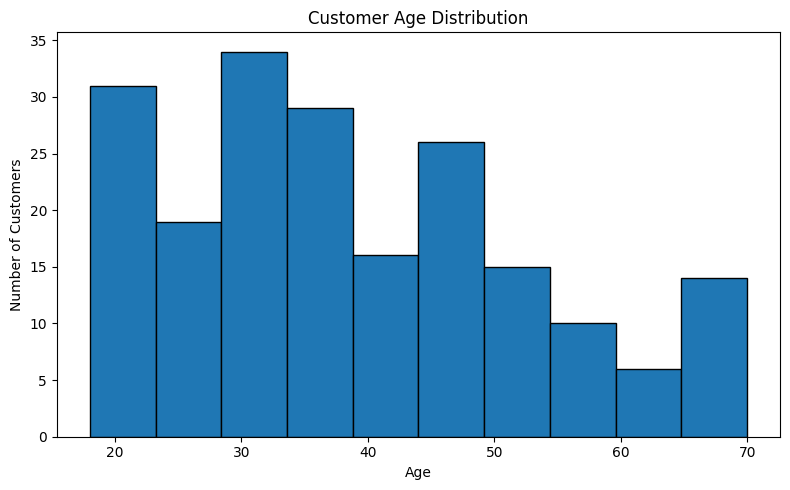

In [ ]:
# ============================================
# STEP 6.2: AGE DISTRIBUTION
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    df_clean["Age"],
    bins=10,
    edgecolor="black"
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

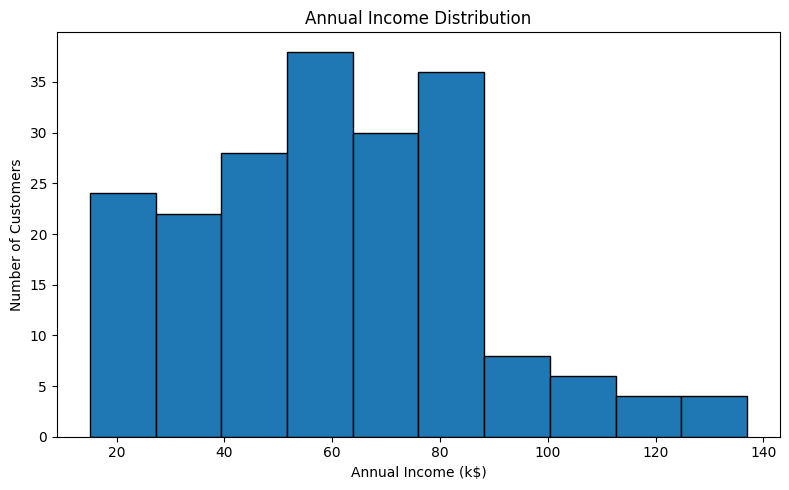

In [ ]:
# ============================================
# STEP 6.3: ANNUAL INCOME DISTRIBUTION
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    df_clean["Annual Income (k$)"],
    bins=10,
    edgecolor="black"
)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

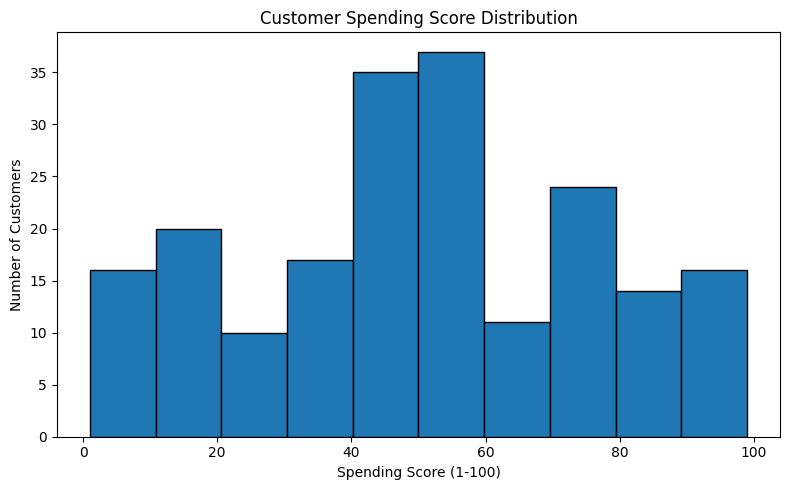

In [ ]:
# ============================================
# STEP 6.4: SPENDING SCORE DISTRIBUTION
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    df_clean["Spending Score (1-100)"],
    bins=10,
    edgecolor="black"
)

plt.title("Customer Spending Score Distribution")
plt.xlabel("Spending Score (1-100)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

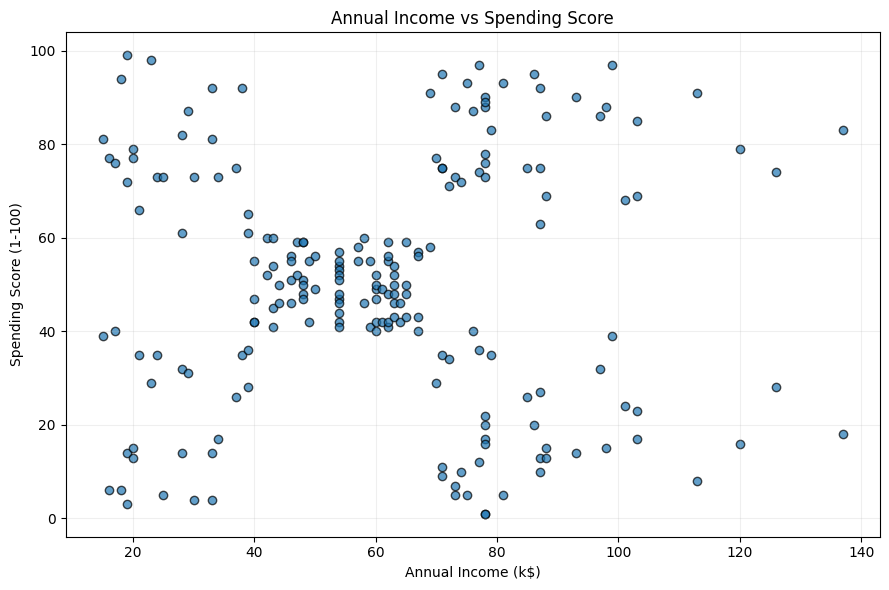

In [ ]:
# ============================================
# STEP 6.5: INCOME VS SPENDING SCORE
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.scatter(
    df_clean["Annual Income (k$)"],
    df_clean["Spending Score (1-100)"],
    alpha=0.7,
    edgecolors="black"
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# STEP 7: FEATURE SELECTION
# ============================================

features = df_clean[
    ["Annual Income (k$)", "Spending Score (1-100)"]
].copy()

print("Selected features:")
print(features.columns.tolist())

print("\nFeature shape:")
print(features.shape)

print("\nFirst 5 rows:")
display(features.head())

Selected features:
['Annual Income (k$)', 'Spending Score (1-100)']

Feature shape:
(200, 2)

First 5 rows:


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [ ]:
# ============================================
# STEP 8: FEATURE SCALING
# ============================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(features)

print("Feature scaling completed successfully!")
print("\nScaled data shape:")
print(X_scaled.shape)

print("\nFirst 5 scaled rows:")
print(X_scaled[:5])

Feature scaling completed successfully!

Scaled data shape:
(200, 2)

First 5 scaled rows:
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


WCSS values:
K = 1: WCSS = 400.00
K = 2: WCSS = 269.69
K = 3: WCSS = 157.70
K = 4: WCSS = 108.92
K = 5: WCSS = 65.57
K = 6: WCSS = 55.06
K = 7: WCSS = 44.86
K = 8: WCSS = 37.23
K = 9: WCSS = 32.39
K = 10: WCSS = 29.98


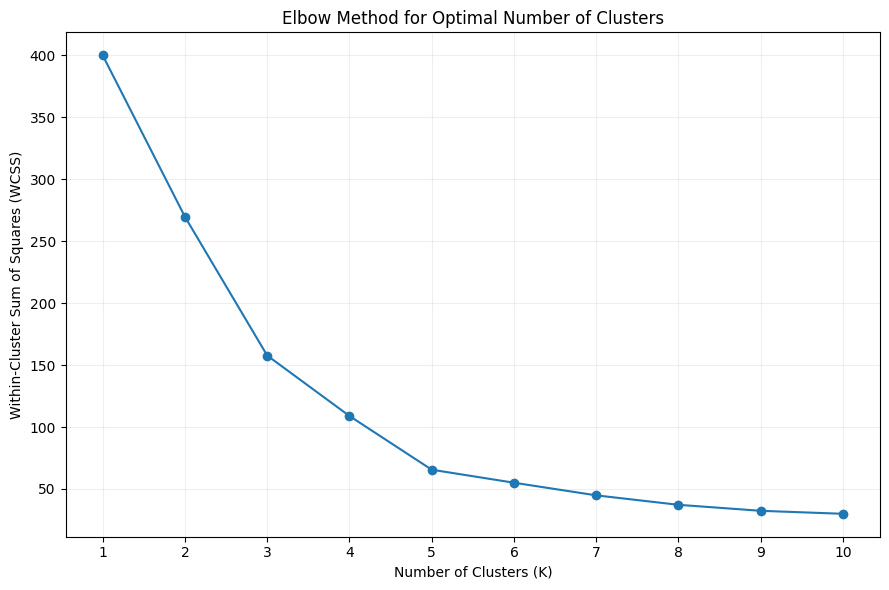

In [ ]:
# ============================================
# STEP 9: ELBOW METHOD
# ============================================

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

print("WCSS values:")
for k, value in enumerate(wcss, start=1):
    print(f"K = {k}: WCSS = {value:.2f}")

plt.figure(figsize=(9, 6))

plt.plot(
    range(1, 11),
    wcss,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.xticks(range(1, 11))
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

Silhouette Scores:
K = 2: Silhouette Score = 0.321
K = 3: Silhouette Score = 0.467
K = 4: Silhouette Score = 0.494
K = 5: Silhouette Score = 0.555
K = 6: Silhouette Score = 0.540
K = 7: Silhouette Score = 0.528
K = 8: Silhouette Score = 0.455
K = 9: Silhouette Score = 0.457
K = 10: Silhouette Score = 0.443

Best K according to Silhouette Score: 5
Best Silhouette Score: 0.555


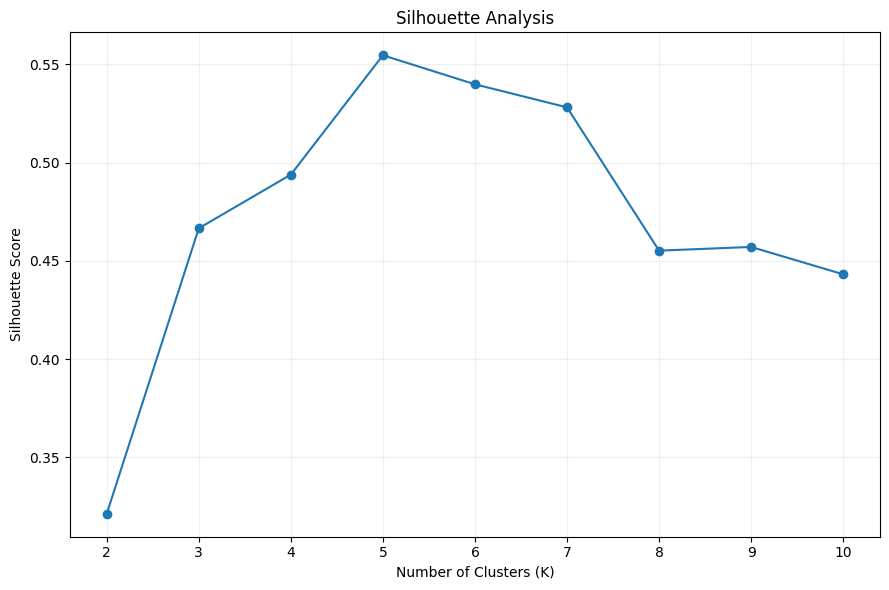

In [ ]:
# ============================================
# STEP 10: SILHOUETTE ANALYSIS
# ============================================

from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

print("Silhouette Scores:")
for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.3f}")

best_k = range(2, 11)[silhouette_scores.index(max(silhouette_scores))]

print("\nBest K according to Silhouette Score:", best_k)
print(
    "Best Silhouette Score:",
    round(max(silhouette_scores), 3)
)

plt.figure(figsize=(9, 6))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Analysis")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
# STEP 11.1 — Final K-Means Clustering Model

from sklearn.cluster import KMeans

# Use the best K found from Silhouette Analysis
optimal_k = best_k

# Create final K-Means model
kmeans_final = KMeans(
    n_clusters=optimal_k,
    init="k-means++",
    random_state=42,
    n_init=10
)

# Create a separate modeling dataset
df_model = df_clean.copy()

# Assign cluster labels
df_model["Cluster"] = kmeans_final.fit_predict(X_scaled)

print("Final K-Means model created successfully!")
print("Optimal number of clusters:", optimal_k)

print("\nCluster distribution:")
print(df_model["Cluster"].value_counts().sort_index())

print("\nFirst 10 rows with cluster labels:")
display(df_model.head(10))

Final K-Means model created successfully!
Optimal number of clusters: 5

Cluster distribution:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

First 10 rows with cluster labels:


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
5,6,Female,22,17,76,2
6,7,Female,35,18,6,4
7,8,Female,23,18,94,2
8,9,Male,64,19,3,4
9,10,Female,30,19,72,2


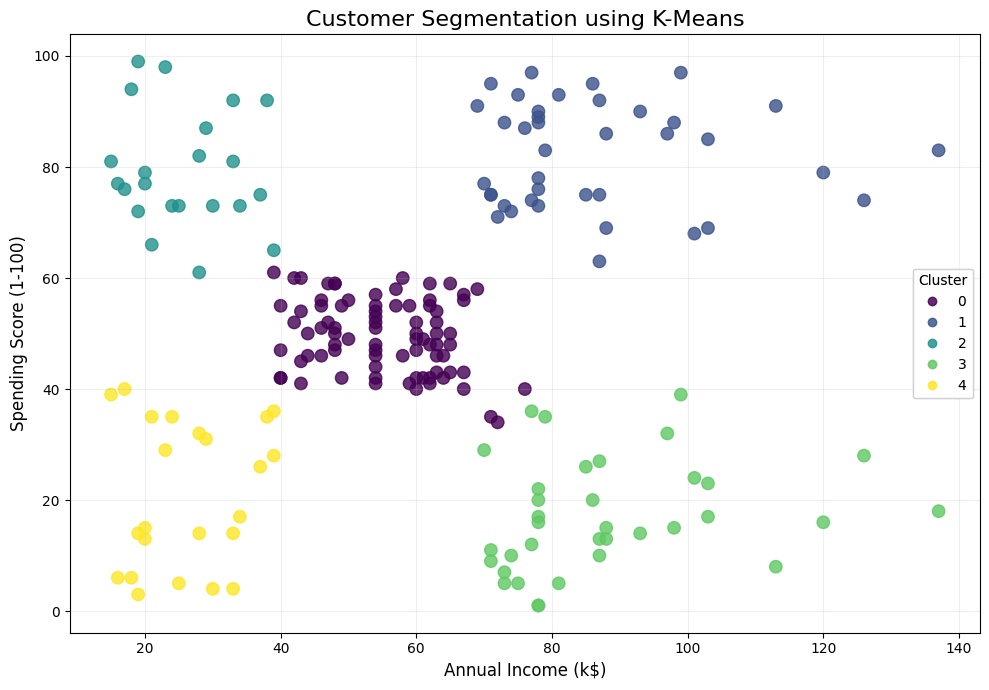

In [ ]:
# STEP 11.2 — Customer Cluster Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    df_model["Annual Income (k$)"],
    df_model["Spending Score (1-100)"],
    c=df_model["Cluster"],
    s=80,
    alpha=0.8
)

plt.title("Customer Segmentation using K-Means", fontsize=16)
plt.xlabel("Annual Income (k$)", fontsize=12)
plt.ylabel("Spending Score (1-100)", fontsize=12)
plt.grid(alpha=0.2)

# Add legend
legend = plt.legend(
    *scatter.legend_elements(),
    title="Cluster",
    loc="best"
)

plt.gca().add_artist(legend)

plt.tight_layout()
plt.show()

In [ ]:
# STEP 11.3 — Cluster Profiles

cluster_profiles = df_model.groupby("Cluster").agg(
    Customer_Count=("CustomerID", "count"),
    Average_Age=("Age", "mean"),
    Average_Income=("Annual Income (k$)", "mean"),
    Average_Spending_Score=("Spending Score (1-100)", "mean")
).reset_index()

# Round numerical values for professional presentation
cluster_profiles["Average_Age"] = cluster_profiles["Average_Age"].round(1)
cluster_profiles["Average_Income"] = cluster_profiles["Average_Income"].round(1)
cluster_profiles["Average_Spending_Score"] = cluster_profiles["Average_Spending_Score"].round(1)

print("===== CUSTOMER CLUSTER PROFILES =====")
display(cluster_profiles)

===== CUSTOMER CLUSTER PROFILES =====


,Cluster,Customer_Count,Average_Age,Average_Income,Average_Spending_Score
0,0,81,42.7,55.3,49.5
1,1,39,32.7,86.5,82.1
2,2,22,25.3,25.7,79.4
3,3,35,41.1,88.2,17.1
4,4,23,45.2,26.3,20.9


In [ ]:
# STEP 11.4 — Professional Cluster Naming

def assign_cluster_name(row):
    income = row["Average_Income"]
    spending = row["Average_Spending_Score"]

    if income >= 60 and spending >= 60:
        return "High-Value Customers"
    elif income >= 60 and spending < 40:
        return "High-Income Low-Spenders"
    elif income < 40 and spending >= 60:
        return "Budget High-Spenders"
    elif income < 40 and spending < 40:
        return "Budget Low-Spenders"
    else:
        return "Average Customers"


cluster_profiles["Customer_Segment"] = cluster_profiles.apply(
    assign_cluster_name,
    axis=1
)

print("===== FINAL CUSTOMER SEGMENTS =====")
display(cluster_profiles)

===== FINAL CUSTOMER SEGMENTS =====


,Cluster,Customer_Count,Average_Age,Average_Income,Average_Spending_Score,Customer_Segment
0,0,81,42.7,55.3,49.5,Average Customers
1,1,39,32.7,86.5,82.1,High-Value Customers
2,2,22,25.3,25.7,79.4,Budget High-Spenders
3,3,35,41.1,88.2,17.1,High-Income Low-Spenders
4,4,23,45.2,26.3,20.9,Budget Low-Spenders


===== CUSTOMERS BY SEGMENT =====


,Customer Count
Customer_Segment,
Average Customers,81
High-Value Customers,39
High-Income Low-Spenders,35
Budget Low-Spenders,23
Budget High-Spenders,22


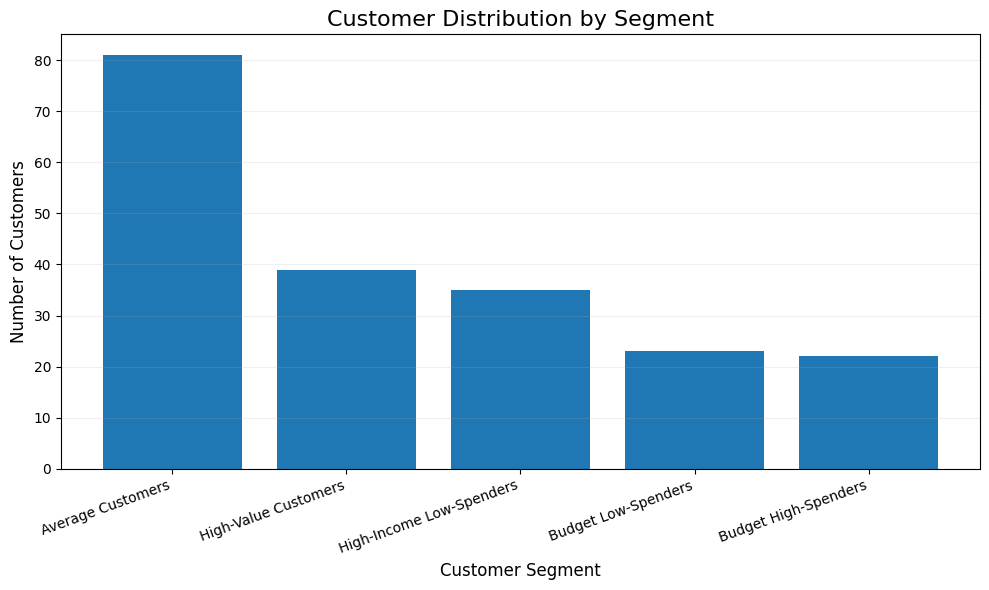

In [ ]:
# STEP 12 — Customer Count by Segment

import matplotlib.pyplot as plt

# Merge segment names with customer-level data
segment_map = cluster_profiles.set_index("Cluster")["Customer_Segment"].to_dict()

df_model["Customer_Segment"] = df_model["Cluster"].map(segment_map)

# Count customers in each segment
segment_counts = (
    df_model["Customer_Segment"]
    .value_counts()
    .sort_values(ascending=False)
)

print("===== CUSTOMERS BY SEGMENT =====")
display(segment_counts.to_frame("Customer Count"))

# Create chart
plt.figure(figsize=(10, 6))

plt.bar(
    segment_counts.index,
    segment_counts.values
)

plt.title("Customer Distribution by Segment", fontsize=16)
plt.xlabel("Customer Segment", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
# STEP 13 — Save Processed Dataset

import os

# Create project output folder
os.makedirs("outputs", exist_ok=True)

# Save the final customer dataset with cluster assignments
output_file = "outputs/customer_segments.csv"

df_model.to_csv(output_file, index=False)

print("Processed dataset saved successfully!")
print("File location:", output_file)

# Verify saved file
print("\nSaved dataset shape:", df_model.shape)
print("\nColumns:")
print(df_model.columns.tolist())

Processed dataset saved successfully!
File location: outputs/customer_segments.csv

Saved dataset shape: (200, 7)

Columns:
['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster', 'Customer_Segment']


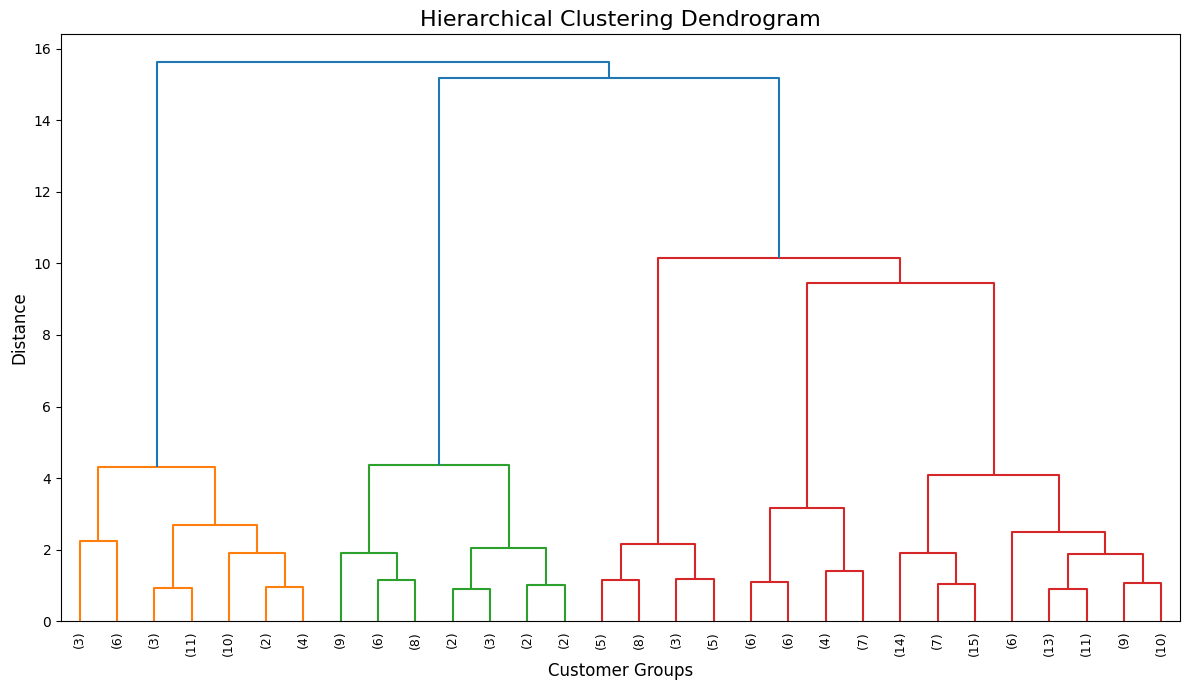

In [ ]:
# STEP 14 — Hierarchical Clustering Dendrogram

import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Create hierarchical clustering linkage
Z = linkage(X_scaled, method="ward")

# Plot dendrogram
plt.figure(figsize=(12, 7))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=9
)

plt.title("Hierarchical Clustering Dendrogram", fontsize=16)
plt.xlabel("Customer Groups", fontsize=12)
plt.ylabel("Distance", fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# STEP 15 — Hierarchical Clustering Validation

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Create Agglomerative Clustering model
hierarchical_model = AgglomerativeClustering(
    n_clusters=optimal_k,
    linkage="ward"
)

# Generate hierarchical cluster labels
hierarchical_labels = hierarchical_model.fit_predict(X_scaled)

# Calculate silhouette score
hierarchical_silhouette = silhouette_score(
    X_scaled,
    hierarchical_labels
)

print("===== HIERARCHICAL CLUSTERING VALIDATION =====")
print("Number of clusters:", optimal_k)
print("Silhouette Score:", round(hierarchical_silhouette, 3))

print("\nCluster distribution:")
print(
    pd.Series(hierarchical_labels)
    .value_counts()
    .sort_index()
)

===== HIERARCHICAL CLUSTERING VALIDATION =====
Number of clusters: 5
Silhouette Score: 0.554

Cluster distribution:
0    32
1    39
2    85
3    21
4    23
Name: count, dtype: int64


In [ ]:
# STEP 16 — Clustering Algorithm Comparison

from sklearn.metrics import silhouette_score

# Calculate K-Means silhouette score
kmeans_silhouette = silhouette_score(
    X_scaled,
    df_model["Cluster"]
)

# Hierarchical score was calculated in Step 15
comparison = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical Clustering"
    ],
    "Silhouette Score": [
        round(kmeans_silhouette, 3),
        round(hierarchical_silhouette, 3)
    ]
})

print("===== CLUSTERING ALGORITHM COMPARISON =====")
display(comparison)

# Identify the better-performing algorithm
if kmeans_silhouette > hierarchical_silhouette:
    print("Best performing algorithm: K-Means")
elif hierarchical_silhouette > kmeans_silhouette:
    print("Best performing algorithm: Hierarchical Clustering")
else:
    print("Both algorithms have the same Silhouette Score.")

===== CLUSTERING ALGORITHM COMPARISON =====


,Algorithm,Silhouette Score
0,K-Means,0.555
1,Hierarchical Clustering,0.554


Best performing algorithm: K-Means


In [ ]:
# STEP 17 — Final Customer Segment Summary

final_summary = cluster_profiles[
    [
        "Cluster",
        "Customer_Segment",
        "Customer_Count",
        "Average_Age",
        "Average_Income",
        "Average_Spending_Score"
    ]
].copy()

# Calculate percentage of total customers
final_summary["Customer_Percentage"] = (
    final_summary["Customer_Count"]
    / len(df_model)
    * 100
).round(1)

# Sort by cluster number
final_summary = final_summary.sort_values("Cluster").reset_index(drop=True)

print("===== FINAL CUSTOMER SEGMENT SUMMARY =====")
display(final_summary)

print("\nTotal customers analyzed:", len(df_model))
print("Total segments:", final_summary["Cluster"].nunique())

===== FINAL CUSTOMER SEGMENT SUMMARY =====


,Cluster,Customer_Segment,Customer_Count,Average_Age,Average_Income,Average_Spending_Score,Customer_Percentage
0,0,Average Customers,81,42.7,55.3,49.5,40.5
1,1,High-Value Customers,39,32.7,86.5,82.1,19.5
2,2,Budget High-Spenders,22,25.3,25.7,79.4,11.0
3,3,High-Income Low-Spenders,35,41.1,88.2,17.1,17.5
4,4,Budget Low-Spenders,23,45.2,26.3,20.9,11.5



Total customers analyzed: 200
Total segments: 5


In [ ]:
# STEP 18 — Save Final Segment Summary

import os

# Make sure outputs folder exists
os.makedirs("outputs", exist_ok=True)

# Save final summary
summary_file = "outputs/final_segment_summary.csv"

final_summary.to_csv(summary_file, index=False)

print("Final segment summary saved successfully!")
print("File:", summary_file)

# Verify
print("\nSaved rows:", len(final_summary))
print("Saved columns:", len(final_summary.columns))

Final segment summary saved successfully!
File: outputs/final_segment_summary.csv

Saved rows: 5
Saved columns: 7


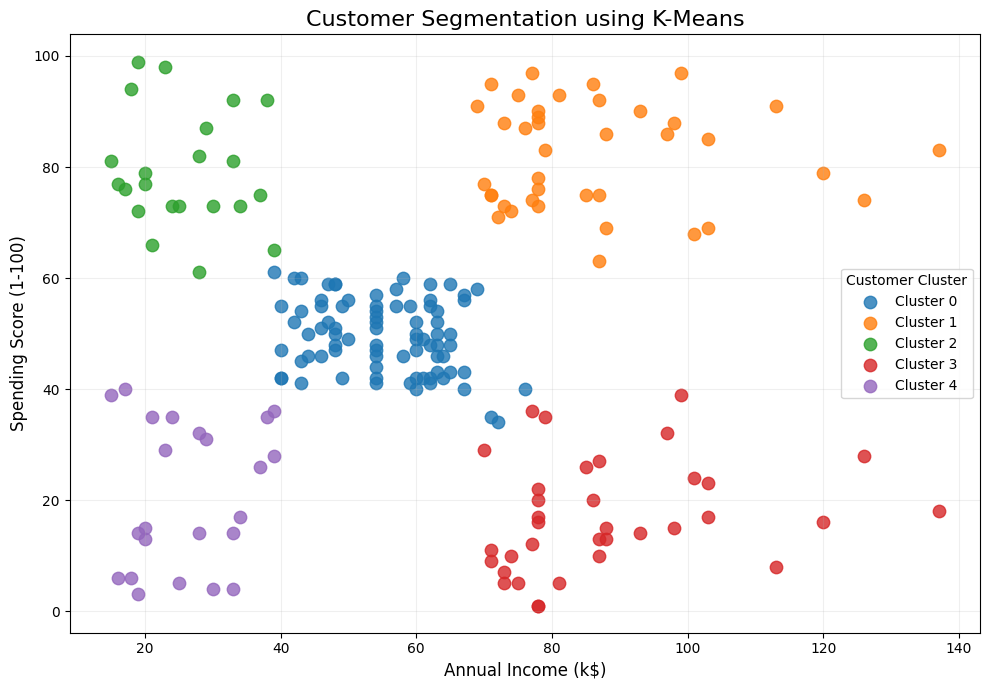

Cluster visualization saved successfully!
File: outputs/customer_clusters.png


In [ ]:
# STEP 19 — Save Final Cluster Visualization

import matplotlib.pyplot as plt
import os

os.makedirs("outputs", exist_ok=True)

plt.figure(figsize=(10, 7))

for cluster in sorted(df_model["Cluster"].unique()):
    cluster_data = df_model[df_model["Cluster"] == cluster]

    plt.scatter(
        cluster_data["Annual Income (k$)"],
        cluster_data["Spending Score (1-100)"],
        s=80,
        alpha=0.8,
        label=f"Cluster {cluster}"
    )

plt.title("Customer Segmentation using K-Means", fontsize=16)
plt.xlabel("Annual Income (k$)", fontsize=12)
plt.ylabel("Spending Score (1-100)", fontsize=12)
plt.legend(title="Customer Cluster")
plt.grid(alpha=0.2)
plt.tight_layout()

# Save image
cluster_plot_file = "outputs/customer_clusters.png"
plt.savefig(cluster_plot_file, dpi=300, bbox_inches="tight")

plt.show()

print("Cluster visualization saved successfully!")
print("File:", cluster_plot_file)

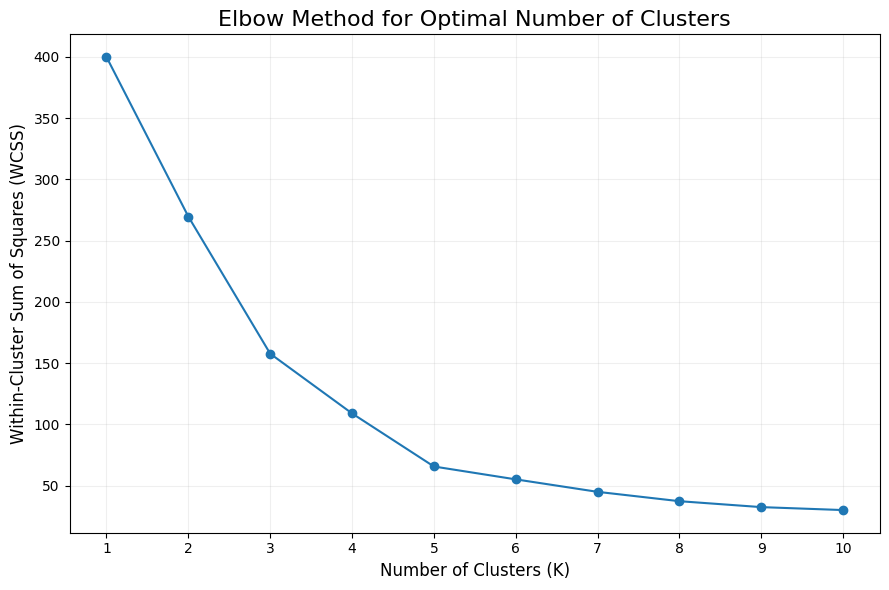

Elbow curve saved successfully!
File: outputs/elbow_curve.png


In [ ]:
# STEP 20 — Save Elbow Curve

import matplotlib.pyplot as plt
import os

os.makedirs("outputs", exist_ok=True)

plt.figure(figsize=(9, 6))

plt.plot(
    range(1, 11),
    wcss,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters", fontsize=16)
plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("Within-Cluster Sum of Squares (WCSS)", fontsize=12)
plt.xticks(range(1, 11))
plt.grid(alpha=0.2)
plt.tight_layout()

# Save high-quality image
elbow_file = "outputs/elbow_curve.png"
plt.savefig(elbow_file, dpi=300, bbox_inches="tight")

plt.show()

print("Elbow curve saved successfully!")
print("File:", elbow_file)

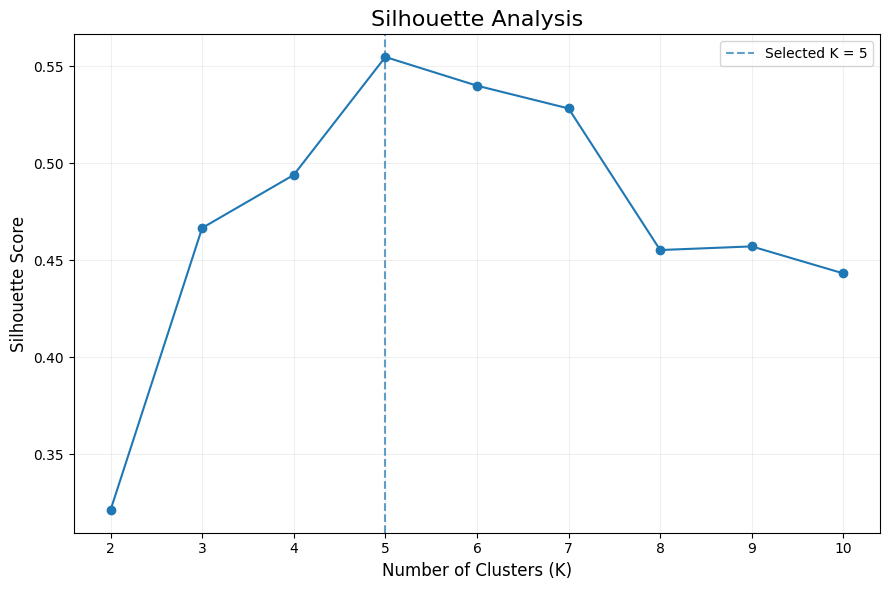

Silhouette analysis saved successfully!
File: outputs/silhouette_analysis.png


In [ ]:
# STEP 21 — Save Silhouette Analysis

import matplotlib.pyplot as plt
import os

os.makedirs("outputs", exist_ok=True)

k_values = list(range(2, 11))

plt.figure(figsize=(9, 6))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Analysis", fontsize=16)
plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("Silhouette Score", fontsize=12)
plt.xticks(k_values)
plt.grid(alpha=0.2)

# Highlight the selected K
plt.axvline(
    optimal_k,
    linestyle="--",
    alpha=0.7,
    label=f"Selected K = {optimal_k}"
)

plt.legend()
plt.tight_layout()

# Save high-quality image
silhouette_file = "outputs/silhouette_analysis.png"
plt.savefig(silhouette_file, dpi=300, bbox_inches="tight")

plt.show()

print("Silhouette analysis saved successfully!")
print("File:", silhouette_file)

In [ ]:
# STEP 22 — Model Evaluation Summary

model_evaluation = pd.DataFrame({
    "Metric": [
        "Selected Number of Clusters (K)",
        "K-Means Silhouette Score",
        "Hierarchical Silhouette Score",
        "Customers Analyzed",
        "Features Used"
    ],
    "Value": [
        optimal_k,
        round(kmeans_silhouette, 3),
        round(hierarchical_silhouette, 3),
        len(df_model),
        "Annual Income + Spending Score"
    ]
})

print("===== FINAL MODEL EVALUATION =====")
display(model_evaluation)

===== FINAL MODEL EVALUATION =====


,Metric,Value
0,Selected Number of Clusters (K),5
1,K-Means Silhouette Score,0.555
2,Hierarchical Silhouette Score,0.554
3,Customers Analyzed,200
4,Features Used,Annual Income + Spending Score


In [ ]:
# STEP 23 — Prepare Dashboard Dataset

dashboard_data = df_model.copy()

# Save the complete dataset for the dashboard
dashboard_file = "outputs/dashboard_data.csv"

dashboard_data.to_csv(
    dashboard_file,
    index=False
)

print("Dashboard dataset created successfully!")
print("File:", dashboard_file)

print("\nDataset shape:", dashboard_data.shape)

print("\nDashboard columns:")
print(dashboard_data.columns.tolist())

Dashboard dataset created successfully!
File: outputs/dashboard_data.csv

Dataset shape: (200, 7)

Dashboard columns:
['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster', 'Customer_Segment']


In [ ]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 91.2 MB/s eta 0:00:00


In [ ]:
# STEP 25 — Create Streamlit Dashboard

app_code = '''
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(
    page_title="Customer Segmentation Dashboard",
    page_icon="📊",
    layout="wide"
)

st.title("📊 Customer Segmentation Dashboard")
st.markdown(
    "Interactive customer segmentation analysis using K-Means clustering."
)

# Load data
DATA_URL = "outputs/dashboard_data.csv"

@st.cache_data
def load_data():
    return pd.read_csv(DATA_URL)

df = load_data()

# Sidebar filters
st.sidebar.header("Filters")

segments = sorted(df["Customer_Segment"].unique())

selected_segments = st.sidebar.multiselect(
    "Select Customer Segment",
    segments,
    default=segments
)

filtered_df = df[
    df["Customer_Segment"].isin(selected_segments)
]

# KPI section
col1, col2, col3, col4 = st.columns(4)

col1.metric(
    "Customers",
    len(filtered_df)
)

col2.metric(
    "Avg Age",
    f"{filtered_df['Age'].mean():.1f}"
)

col3.metric(
    "Avg Income",
    f"{filtered_df['Annual Income (k$)'].mean():.1f}k"
)

col4.metric(
    "Avg Spending Score",
    f"{filtered_df['Spending Score (1-100)'].mean():.1f}"
)

st.divider()

# Customer distribution
st.subheader("Customer Distribution by Segment")

segment_counts = (
    filtered_df["Customer_Segment"]
    .value_counts()
    .sort_values(ascending=False)
)

fig1, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(
    segment_counts.index,
    segment_counts.values
)

ax1.set_xlabel("Customer Segment")
ax1.set_ylabel("Number of Customers")
ax1.set_title("Customer Distribution")

plt.xticks(rotation=20, ha="right")
plt.tight_layout()

st.pyplot(fig1)

# Income vs Spending
st.subheader("Income vs Spending Score")

fig2, ax2 = plt.subplots(figsize=(10, 6))

for segment in filtered_df["Customer_Segment"].unique():

    segment_data = filtered_df[
        filtered_df["Customer_Segment"] == segment
    ]

    ax2.scatter(
        segment_data["Annual Income (k$)"],
        segment_data["Spending Score (1-100)"],
        s=70,
        alpha=0.8,
        label=segment
    )

ax2.set_xlabel("Annual Income (k$)")
ax2.set_ylabel("Spending Score (1-100)")
ax2.set_title("Customer Segmentation")
ax2.legend()

plt.tight_layout()

st.pyplot(fig2)

# Customer data
st.subheader("Customer Data")

st.dataframe(
    filtered_df,
    use_container_width=True
)

st.caption(
    "Customer segmentation model developed using K-Means clustering."
)
'''

with open("app.py", "w", encoding="utf-8") as file:
    file.write(app_code)

print("app.py created successfully!")
print("File location: app.py")

app.py created successfully!
File location: app.py


In [ ]:
# STEP 26 — Create requirements.txt

requirements = """streamlit
pandas
matplotlib
scikit-learn
scipy
"""

with open("requirements.txt", "w", encoding="utf-8") as file:
    file.write(requirements)

print("requirements.txt created successfully!")
print("\nRequired packages:")
print(requirements)

requirements.txt created successfully!

Required packages:
streamlit
pandas
matplotlib
scikit-learn
scipy



In [ ]:
# STEP 27 — Check Streamlit App

import os

print("Checking required project files...\n")

files_to_check = [
    "app.py",
    "requirements.txt",
    "outputs/dashboard_data.csv"
]

all_files_exist = True

for file in files_to_check:
    if os.path.exists(file):
        print("✓ Found:", file)
    else:
        print("✗ Missing:", file)
        all_files_exist = False

if all_files_exist:
    print("\nAll required files are present!")
    print("The project is ready for the next testing step.")
else:
    print("\nSome files are missing. Do not continue yet.")

Checking required project files...

✓ Found: app.py
✓ Found: requirements.txt
✓ Found: outputs/dashboard_data.csv

All required files are present!
The project is ready for the next testing step.


In [ ]:
# STEP 28 — Run Streamlit App

!streamlit run app.py &>/content/streamlit.log &

import time
time.sleep(5)

print("Streamlit application started.")
print("Next, we will open the running application.")

Streamlit application started.
Next, we will open the running application.


In [ ]:
# STEP 29 — Get Streamlit App URL

!pip install -q pyngrok

from pyngrok import ngrok

# Open a public tunnel to Streamlit
public_url = ngrok.connect(8501)

print("======================================")
print("STREAMLIT APP IS LIVE")
print("======================================")
print("Open this link in your browser:")
print(public_url)

ERROR:pyngrok.process.ngrok:t=2026-09-10T15:03:14+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-09-10T15:03:14+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"


PyngrokNgrokError: The ngrok process errored on start: authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.

In [ ]:
# STEP 29 — Check Streamlit Status

!cat /content/streamlit.log



2026-09-10 15:02:15.810 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.182.204.246:8501



In [ ]:
# STEP 29 — Create a browser-accessible Colab link

from google.colab import output

output.serve_kernel_port_as_window(8501)

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

In [ ]:
# STEP 30 — Open Streamlit inside Colab

from google.colab import output

output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [2]:
# STEP 30 — Create Public Streamlit Link

!npm install -g localtunnel

!lt --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧
added 22 packages in 3s
⠧
⠧3 packages are looking for funding
⠧  run `npm fund` for details
⠧your url is: https://tangy-deer-hunt.loca.lt
^C


In [3]:
# STEP 31 — Check Streamlit Server

!ps aux | grep streamlit

root        3889  0.0  0.0   7340  3520 ?        S    05:57   0:00 /bin/bash -c ps aux | grep streamlit
root        3891  0.0  0.0   6544  2340 ?        S    05:57   0:00 grep streamlit


In [4]:
# STEP 32 — Start Streamlit Properly

!nohup streamlit run app.py --server.port 8501 --server.address 0.0.0.0 > /content/streamlit.log 2>&1 &

import time
time.sleep(8)

print("Streamlit server started.")

Streamlit server started.


In [5]:
# STEP 33 — Verify Streamlit Server

!ps aux | grep "[s]treamlit"

print("\n===== STREAMLIT LOG =====")
!tail -20 /content/streamlit.log


===== STREAMLIT LOG =====
nohup: failed to run command 'streamlit': No such file or directory


In [6]:
# STEP 34 — Reinstall Streamlit Correctly

!python -m pip install -q streamlit

print("Streamlit installation completed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 94.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 88.2 MB/s eta 0:00:00
Streamlit installation completed!


In [7]:
# STEP 35 — Start Streamlit Correctly

!nohup python -m streamlit run app.py --server.port 8501 --server.address 0.0.0.0 > /content/streamlit.log 2>&1 &

import time
time.sleep(8)

print("Streamlit server started successfully.")

Streamlit server started successfully.


In [8]:
# STEP 36 — Verify Streamlit Server

!ps aux | grep "[s]treamlit"

print("\n===== SERVER LOG =====")
!tail -20 /content/streamlit.log


===== SERVER LOG =====
Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py


In [9]:
# STEP 37 — Find app.py

import os

print("Current folder:")
print(os.getcwd())

print("\nSearching for app.py...")

for root, dirs, files in os.walk("/content"):
    if "app.py" in files:
        print("app.py found at:")
        print(os.path.join(root, "app.py"))

Current folder:
/content

Searching for app.py...


In [10]:
# STEP 38 — Recreate app.py

app_code = '''
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(
    page_title="Customer Segmentation Dashboard",
    page_icon="📊",
    layout="wide"
)

st.title("📊 Customer Segmentation Dashboard")
st.write("Interactive customer segmentation analysis using K-Means clustering.")

DATA_FILE = "outputs/dashboard_data.csv"

@st.cache_data
def load_data():
    return pd.read_csv(DATA_FILE)

df = load_data()

st.sidebar.header("Filters")

segments = sorted(df["Customer_Segment"].unique())

selected_segments = st.sidebar.multiselect(
    "Select Customer Segment",
    segments,
    default=segments
)

filtered_df = df[df["Customer_Segment"].isin(selected_segments)]

col1, col2, col3, col4 = st.columns(4)

col1.metric("Customers", len(filtered_df))
col2.metric("Avg Age", f"{filtered_df['Age'].mean():.1f}")
col3.metric("Avg Income", f"{filtered_df['Annual Income (k$)'].mean():.1f}k")
col4.metric(
    "Avg Spending Score",
    f"{filtered_df['Spending Score (1-100)'].mean():.1f}"
)

st.divider()

st.subheader("Customer Distribution by Segment")

segment_counts = filtered_df["Customer_Segment"].value_counts()

fig1, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(segment_counts.index, segment_counts.values)

ax1.set_xlabel("Customer Segment")
ax1.set_ylabel("Number of Customers")
ax1.set_title("Customer Distribution")

plt.xticks(rotation=20, ha="right")
plt.tight_layout()

st.pyplot(fig1)

st.subheader("Income vs Spending Score")

fig2, ax2 = plt.subplots(figsize=(10, 6))

for segment in filtered_df["Customer_Segment"].unique():

    segment_data = filtered_df[
        filtered_df["Customer_Segment"] == segment
    ]

    ax2.scatter(
        segment_data["Annual Income (k$)"],
        segment_data["Spending Score (1-100)"],
        s=70,
        alpha=0.8,
        label=segment
    )

ax2.set_xlabel("Annual Income (k$)")
ax2.set_ylabel("Spending Score (1-100)")
ax2.set_title("Customer Segmentation")
ax2.legend()

plt.tight_layout()

st.pyplot(fig2)

st.subheader("Customer Data")

st.dataframe(
    filtered_df,
    use_container_width=True
)

st.caption("Customer segmentation model developed using K-Means clustering.")
'''

with open("/content/app.py", "w", encoding="utf-8") as file:
    file.write(app_code)

print("app.py recreated successfully!")
print("Location: /content/app.py")

app.py recreated successfully!
Location: /content/app.py


In [11]:
# STEP 39 — Verify app.py

import os

if os.path.exists("/content/app.py"):
    print("✅ app.py found successfully!")
    print("File size:", os.path.getsize("/content/app.py"), "bytes")
else:
    print("❌ app.py not found!")

✅ app.py found successfully!
File size: 2185 bytes


In [12]:
# STEP 40 — Start Streamlit

!nohup python -m streamlit run /content/app.py --server.port 8501 --server.address 0.0.0.0 > /content/streamlit.log 2>&1 &

import time
time.sleep(8)

print("Streamlit server started.")

Streamlit server started.


In [13]:
# STEP 41 — Verify Streamlit Server

!ps aux | grep "[s]treamlit"

print("\n===== STREAMLIT LOG =====")
!tail -20 /content/streamlit.log

root        5893  5.5  0.5 453920 73912 ?        Sl   06:05   0:02 python3 -m streamlit run /content/app.py --server.port 8501 --server.address 0.0.0.0

===== STREAMLIT LOG =====


2026-09-11 06:05:46.354 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.141.153.40:8501



In [15]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [16]:
import os
import subprocess

print("===== STREAMLIT STATUS CHECK =====")

print("\n1. Streamlit version:")
os.system("python -m streamlit --version")

print("\n2. App file exists:")
print(os.path.exists("/content/app.py"))

print("\n3. Dashboard data exists:")
print(os.path.exists("/content/outputs/dashboard_data.csv"))

print("\n4. Streamlit process:")
os.system("ps aux | grep '[s]treamlit'")

===== STREAMLIT STATUS CHECK =====

1. Streamlit version:

2. App file exists:
True

3. Dashboard data exists:
False

4. Streamlit process:


0

In [17]:
import os
import pandas as pd

# Create outputs folder
os.makedirs("/content/outputs", exist_ok=True)

# Check whether df_model exists
print("df_model exists:", "df_model" in globals())

if "df_model" in globals():
    dashboard_file = "/content/outputs/dashboard_data.csv"

    df_model.to_csv(dashboard_file, index=False)

    print("✅ Dashboard data created successfully!")
    print("File:", dashboard_file)
    print("Rows:", len(df_model))
    print("Columns:", len(df_model.columns))

    print("\nColumns:")
    print(df_model.columns.tolist())

else:
    print("❌ df_model is not available.")
    print("We will recreate the model in the next step.")

df_model exists: False
❌ df_model is not available.
We will recreate the model in the next step.


In [18]:
import pandas as pd

url = "https://raw.githubusercontent.com/sharmaroshan/Clustering-of-Mall-Customers/master/Mall_Customers.csv"

df = pd.read_csv(url)

print("✅ Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

✅ Dataset loaded successfully!
Rows: 200
Columns: 5


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [19]:
# STEP 46: Data Cleaning and Feature Selection

df_clean = df.copy()

# Remove duplicate rows
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)

print("Duplicate rows removed:", before - after)

# Check missing values
print("\nMissing values:")
print(df_clean.isnull().sum())

# Select features for clustering
features = df_clean[
    ["Annual Income (k$)", "Spending Score (1-100)"]
].copy()

print("\nSelected features:")
print(features.columns.tolist())

print("\nFeature shape:")
print(features.shape)

print("\nFirst 5 rows:")
display(features.head())

Duplicate rows removed: 0

Missing values:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Selected features:
['Annual Income (k$)', 'Spending Score (1-100)']

Feature shape:
(200, 2)

First 5 rows:


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [20]:
# STEP 47: Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(features)

print("✅ Feature scaling completed successfully!")

print("\nScaled data shape:")
print(X_scaled.shape)

print("\nFirst 5 scaled rows:")
print(X_scaled[:5])

✅ Feature scaling completed successfully!

Scaled data shape:
(200, 2)

First 5 scaled rows:
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


===== SILHOUETTE ANALYSIS =====
K = 2: Silhouette Score = 0.321
K = 3: Silhouette Score = 0.467
K = 4: Silhouette Score = 0.494
K = 5: Silhouette Score = 0.555
K = 6: Silhouette Score = 0.540
K = 7: Silhouette Score = 0.528
K = 8: Silhouette Score = 0.455
K = 9: Silhouette Score = 0.457
K = 10: Silhouette Score = 0.443

✅ Optimal K: 5
✅ Best Silhouette Score: 0.555


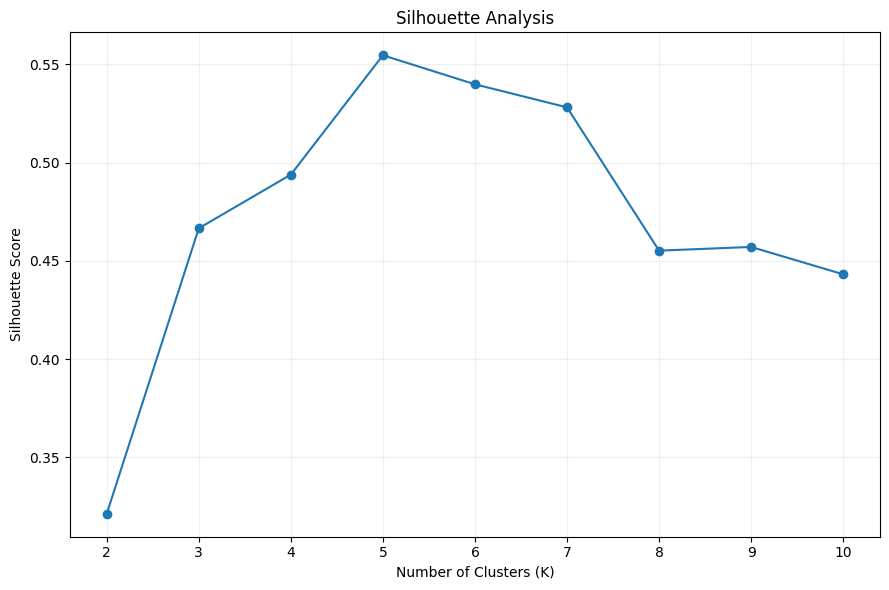

In [21]:
# STEP 48: Find Optimal K using Silhouette Score

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

silhouette_scores = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Find the K with the highest Silhouette Score
optimal_k = range(2, 11)[silhouette_scores.index(max(silhouette_scores))]

print("===== SILHOUETTE ANALYSIS =====")

for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.3f}")

print("\n✅ Optimal K:", optimal_k)
print("✅ Best Silhouette Score:", round(max(silhouette_scores), 3))

# Plot
plt.figure(figsize=(9, 6))
plt.plot(range(2, 11), silhouette_scores, marker="o")
plt.title("Silhouette Analysis")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [22]:
# STEP 49: Train Final K-Means Model

from sklearn.cluster import KMeans

kmeans_final = KMeans(
    n_clusters=optimal_k,
    init="k-means++",
    random_state=42,
    n_init=10
)

df_model = df_clean.copy()

df_model["Cluster"] = kmeans_final.fit_predict(X_scaled)

print("✅ Final K-Means model trained successfully!")
print("Optimal K:", optimal_k)

print("\n===== CLUSTER DISTRIBUTION =====")
print(df_model["Cluster"].value_counts().sort_index())

print("\n===== FIRST 10 CUSTOMERS =====")
display(df_model.head(10))

✅ Final K-Means model trained successfully!
Optimal K: 5

===== CLUSTER DISTRIBUTION =====
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

===== FIRST 10 CUSTOMERS =====


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
5,6,Female,22,17,76,2
6,7,Female,35,18,6,4
7,8,Female,23,18,94,2
8,9,Male,64,19,3,4
9,10,Female,30,19,72,2


In [23]:
# STEP 50: Customer Segment Profiles

cluster_profiles = df_model.groupby("Cluster").agg(
    Customer_Count=("CustomerID", "count"),
    Average_Age=("Age", "mean"),
    Average_Income=("Annual Income (k$)", "mean"),
    Average_Spending_Score=("Spending Score (1-100)", "mean")
).reset_index()

# Round numerical values
cluster_profiles["Average_Age"] = cluster_profiles["Average_Age"].round(1)
cluster_profiles["Average_Income"] = cluster_profiles["Average_Income"].round(1)
cluster_profiles["Average_Spending_Score"] = (
    cluster_profiles["Average_Spending_Score"].round(1)
)

print("===== CUSTOMER SEGMENT PROFILES =====")
display(cluster_profiles)

===== CUSTOMER SEGMENT PROFILES =====


,Cluster,Customer_Count,Average_Age,Average_Income,Average_Spending_Score
0,0,81,42.7,55.3,49.5
1,1,39,32.7,86.5,82.1
2,2,22,25.3,25.7,79.4
3,3,35,41.1,88.2,17.1
4,4,23,45.2,26.3,20.9


In [24]:
# STEP 51: Assign Professional Customer Segment Names

def assign_segment_name(row):
    income = row["Average_Income"]
    spending = row["Average_Spending_Score"]

    if income >= 60 and spending >= 60:
        return "High-Value Customers"
    elif income >= 60 and spending < 40:
        return "High-Income Low-Spenders"
    elif income < 40 and spending >= 60:
        return "Budget High-Spenders"
    elif income < 40 and spending < 40:
        return "Budget Low-Spenders"
    else:
        return "Average Customers"


cluster_profiles["Customer_Segment"] = cluster_profiles.apply(
    assign_segment_name,
    axis=1
)

print("===== FINAL CUSTOMER SEGMENTS =====")
display(cluster_profiles)

===== FINAL CUSTOMER SEGMENTS =====


,Cluster,Customer_Count,Average_Age,Average_Income,Average_Spending_Score,Customer_Segment
0,0,81,42.7,55.3,49.5,Average Customers
1,1,39,32.7,86.5,82.1,High-Value Customers
2,2,22,25.3,25.7,79.4,Budget High-Spenders
3,3,35,41.1,88.2,17.1,High-Income Low-Spenders
4,4,23,45.2,26.3,20.9,Budget Low-Spenders


In [25]:
# STEP 52: Prepare Data for Streamlit Dashboard

import os

# Create outputs folder
os.makedirs("/content/outputs", exist_ok=True)

# Map cluster numbers to professional segment names
segment_map = cluster_profiles.set_index("Cluster")["Customer_Segment"].to_dict()

df_model["Customer_Segment"] = df_model["Cluster"].map(segment_map)

# Save dashboard-ready dataset
dashboard_file = "/content/outputs/dashboard_data.csv"

df_model.to_csv(dashboard_file, index=False)

print("✅ Dashboard data created successfully!")
print("File:", dashboard_file)
print("Rows:", len(df_model))
print("Columns:", len(df_model.columns))

print("\nCustomer segments:")
print(df_model["Customer_Segment"].value_counts())

print("\nFile exists:", os.path.exists(dashboard_file))

✅ Dashboard data created successfully!
File: /content/outputs/dashboard_data.csv
Rows: 200
Columns: 7

Customer segments:
Customer_Segment
Average Customers           81
High-Value Customers        39
High-Income Low-Spenders    35
Budget Low-Spenders         23
Budget High-Spenders        22
Name: count, dtype: int64

File exists: True


In [26]:
# STEP 53: Verify Dashboard Data

import os
import pandas as pd

dashboard_file = "/content/outputs/dashboard_data.csv"

print("===== DASHBOARD DATA VERIFICATION =====")

print("File exists:", os.path.exists(dashboard_file))

if os.path.exists(dashboard_file):
    dashboard_df = pd.read_csv(dashboard_file)

    print("Rows:", dashboard_df.shape[0])
    print("Columns:", dashboard_df.shape[1])

    print("\nColumn Names:")
    print(dashboard_df.columns.tolist())

    print("\nCustomer Segments:")
    print(dashboard_df["Customer_Segment"].value_counts())

    print("\nFirst 5 Records:")
    display(dashboard_df.head())

===== DASHBOARD DATA VERIFICATION =====
File exists: True
Rows: 200
Columns: 7

Column Names:
['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster', 'Customer_Segment']

Customer Segments:
Customer_Segment
Average Customers           81
High-Value Customers        39
High-Income Low-Spenders    35
Budget Low-Spenders         23
Budget High-Spenders        22
Name: count, dtype: int64

First 5 Records:


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster,Customer_Segment
0,1,Male,19,15,39,4,Budget Low-Spenders
1,2,Male,21,15,81,2,Budget High-Spenders
2,3,Female,20,16,6,4,Budget Low-Spenders
3,4,Female,23,16,77,2,Budget High-Spenders
4,5,Female,31,17,40,4,Budget Low-Spenders


In [27]:
# STEP 54: Create Professional Streamlit Dashboard

app_code = r'''
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(
    page_title="Customer Segmentation Dashboard",
    page_icon="📊",
    layout="wide"
)

DATA_FILE = "outputs/dashboard_data.csv"


@st.cache_data
def load_data():
    return pd.read_csv(DATA_FILE)


# -----------------------------
# Load Data
# -----------------------------
try:
    df = load_data()
except FileNotFoundError:
    st.error("Dashboard data file not found: outputs/dashboard_data.csv")
    st.stop()


# -----------------------------
# Header
# -----------------------------
st.title("📊 Customer Segmentation Dashboard")
st.write(
    "Interactive customer segmentation analysis using K-Means clustering."
)

st.divider()


# -----------------------------
# Sidebar Filters
# -----------------------------
st.sidebar.header("Dashboard Filters")

segments = sorted(df["Customer_Segment"].dropna().unique().tolist())

selected_segments = st.sidebar.multiselect(
    "Customer Segment",
    options=segments,
    default=segments
)

filtered_df = df[
    df["Customer_Segment"].isin(selected_segments)
]


# -----------------------------
# KPI Metrics
# -----------------------------
if len(filtered_df) > 0:

    col1, col2, col3, col4 = st.columns(4)

    col1.metric(
        "Total Customers",
        len(filtered_df)
    )

    col2.metric(
        "Average Age",
        f"{filtered_df['Age'].mean():.1f}"
    )

    col3.metric(
        "Average Income",
        f"{filtered_df['Annual Income (k$)'].mean():.1f}k"
    )

    col4.metric(
        "Average Spending Score",
        f"{filtered_df['Spending Score (1-100)'].mean():.1f}"
    )

else:
    st.warning("Please select at least one customer segment.")
    st.stop()


st.divider()


# -----------------------------
# Customer Distribution
# -----------------------------
st.subheader("Customer Distribution by Segment")

segment_counts = (
    filtered_df["Customer_Segment"]
    .value_counts()
    .sort_values(ascending=False)
)

fig1, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(
    segment_counts.index,
    segment_counts.values
)

ax1.set_xlabel("Customer Segment")
ax1.set_ylabel("Number of Customers")
ax1.set_title("Customer Distribution")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()

st.pyplot(
    fig1,
    use_container_width=True
)

plt.close(fig1)


# -----------------------------
# Income vs Spending
# -----------------------------
st.subheader("Income vs Spending Score")

fig2, ax2 = plt.subplots(figsize=(10, 6))

for segment in filtered_df["Customer_Segment"].unique():

    segment_data = filtered_df[
        filtered_df["Customer_Segment"] == segment
    ]

    ax2.scatter(
        segment_data["Annual Income (k$)"],
        segment_data["Spending Score (1-100)"],
        s=70,
        alpha=0.8,
        label=segment
    )

ax2.set_xlabel("Annual Income (k$)")
ax2.set_ylabel("Spending Score (1-100)")
ax2.set_title("Customer Segmentation")

ax2.legend(
    title="Customer Segment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

st.pyplot(
    fig2,
    use_container_width=True
)

plt.close(fig2)


# -----------------------------
# Segment Summary
# -----------------------------
st.subheader("Segment Summary")

summary = (
    filtered_df
    .groupby("Customer_Segment")
    .agg(
        Customers=("CustomerID", "count"),
        Average_Age=("Age", "mean"),
        Average_Income=("Annual Income (k$)", "mean"),
        Average_Spending_Score=("Spending Score (1-100)", "mean")
    )
    .reset_index()
)

summary["Average_Age"] = summary["Average_Age"].round(1)
summary["Average_Income"] = summary["Average_Income"].round(1)
summary["Average_Spending_Score"] = (
    summary["Average_Spending_Score"].round(1)
)

st.dataframe(
    summary,
    use_container_width=True,
    hide_index=True
)


# -----------------------------
# Customer Data
# -----------------------------
st.subheader("Customer-Level Data")

display_columns = [
    "CustomerID",
    "Genre",
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)",
    "Cluster",
    "Customer_Segment"
]

st.dataframe(
    filtered_df[display_columns],
    use_container_width=True,
    hide_index=True
)


# -----------------------------
# Footer
# -----------------------------
st.divider()

st.caption(
    "Customer Segmentation Project | K-Means Clustering | "
    "Interactive Streamlit Dashboard"
)
'''

with open("/content/app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("✅ Professional app.py created successfully!")
print("File location: /content/app.py")
print("File size:", os.path.getsize("/content/app.py"), "bytes")

✅ Professional app.py created successfully!
File location: /content/app.py
File size: 4449 bytes


In [28]:
# STEP 55: Validate Streamlit App

import py_compile
import os

app_file = "/content/app.py"

try:
    py_compile.compile(app_file, doraise=True)
    print("✅ app.py syntax check passed!")
    print("✅ No Python syntax errors found.")
    print("File exists:", os.path.exists(app_file))
except Exception as e:
    print("❌ Error found in app.py:")
    print(e)

✅ app.py syntax check passed!
✅ No Python syntax errors found.
File exists: True


In [29]:
# STEP 56: Start Streamlit Dashboard

import os
import time

# Stop any old Streamlit process
os.system("pkill -f 'streamlit run' || true")

# Start Streamlit in background
os.system(
    "nohup python -m streamlit run /content/app.py "
    "--server.port 8501 "
    "--server.address 0.0.0.0 "
    "> /content/streamlit.log 2>&1 &"
)

time.sleep(8)

print("✅ Streamlit dashboard started!")
print("\n===== SERVER CHECK =====")
os.system("ps aux | grep '[s]treamlit'")

print("\n===== STREAMLIT LOG =====")
os.system("cat /content/streamlit.log")

✅ Streamlit dashboard started!

===== SERVER CHECK =====

===== STREAMLIT LOG =====


0

In [30]:
# STEP 57: Verify Streamlit Server

import os
import time

print("===== STREAMLIT PROCESS =====")
os.system("ps aux | grep '[s]treamlit'")

print("\n===== PORT 8501 CHECK =====")
os.system("curl -I --max-time 10 http://127.0.0.1:8501")

print("\n===== APP LOG =====")
os.system("tail -30 /content/streamlit.log")

===== STREAMLIT PROCESS =====

===== PORT 8501 CHECK =====

===== APP LOG =====


0

In [31]:
from google.colab import output

print("Opening Streamlit dashboard...")
output.serve_kernel_port_as_iframe(8501)

Opening Streamlit dashboard...


<IPython.core.display.Javascript object>

In [37]:
import os

print("app.py:", os.path.exists("/content/app.py"))
print("dashboard_data.csv:", os.path.exists("/content/outputs/dashboard_data.csv"))
print("outputs folder:", os.path.exists("/content/outputs"))

print("\nFiles inside outputs:")
print(os.listdir("/content/outputs"))

app.py: True
dashboard_data.csv: True
outputs folder: True

Files inside outputs:
['dashboard_data.csv']


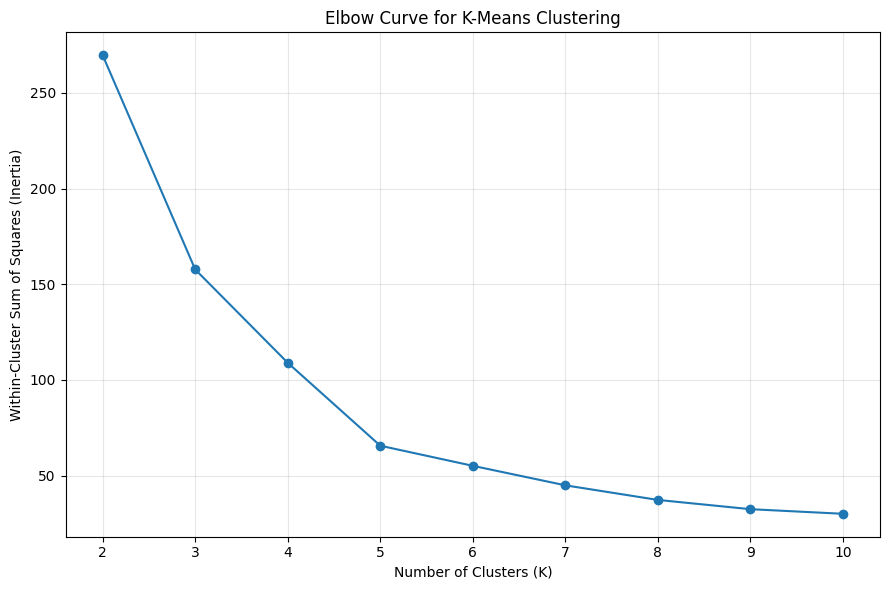

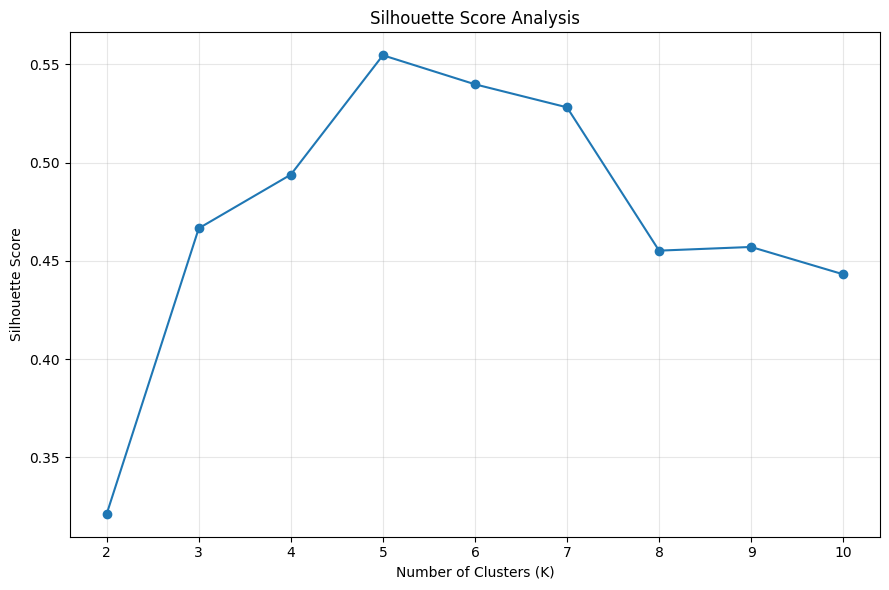

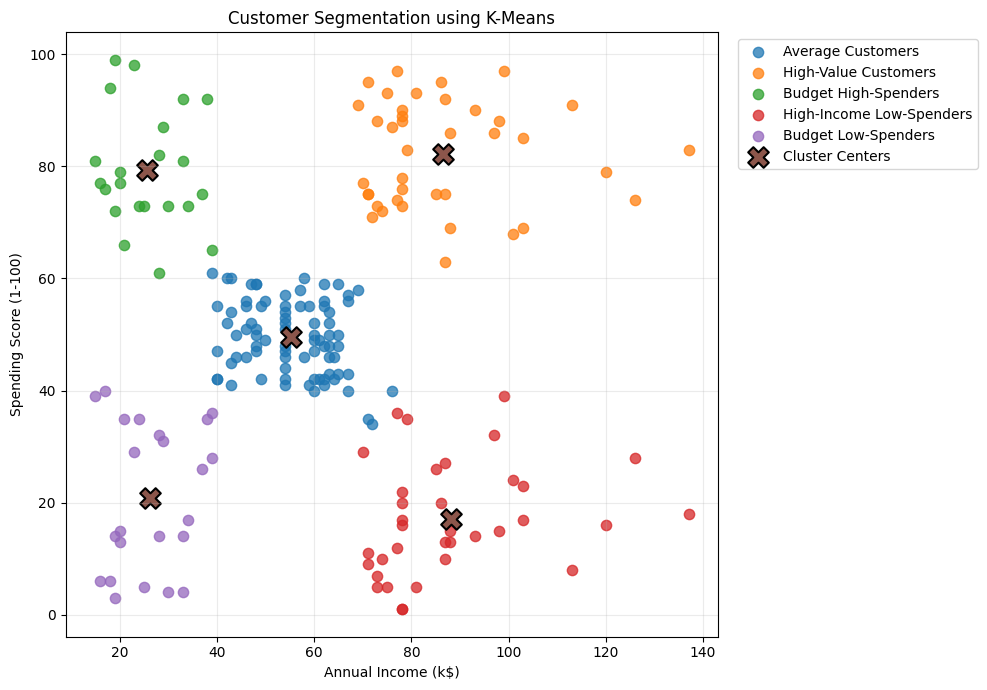

✅ All 3 professional charts generated successfully!

Files created:
1. elbow_curve.png
2. silhouette_analysis.png
3. customer_clusters.png


In [38]:
import os
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

os.makedirs("/content/outputs", exist_ok=True)

# Use the already prepared scaled data
X = X_scaled

# --------------------------------------------------
# 1. Elbow Curve
# --------------------------------------------------
inertia_values = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42,
        n_init=10
    )
    model.fit(X)
    inertia_values.append(model.inertia_)

plt.figure(figsize=(9, 6))
plt.plot(range(2, 11), inertia_values, marker="o")
plt.title("Elbow Curve for K-Means Clustering")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/content/outputs/elbow_curve.png", dpi=300)
plt.show()


# --------------------------------------------------
# 2. Silhouette Analysis
# --------------------------------------------------
silhouette_values = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42,
        n_init=10
    )
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_values.append(score)

plt.figure(figsize=(9, 6))
plt.plot(range(2, 11), silhouette_values, marker="o")
plt.title("Silhouette Score Analysis")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/content/outputs/silhouette_analysis.png", dpi=300)
plt.show()


# --------------------------------------------------
# 3. Customer Cluster Visualization
# --------------------------------------------------
plt.figure(figsize=(10, 7))

for cluster in sorted(df_model["Cluster"].unique()):
    cluster_data = df_model[df_model["Cluster"] == cluster]

    plt.scatter(
        cluster_data["Annual Income (k$)"],
        cluster_data["Spending Score (1-100)"],
        label=cluster_data["Customer_Segment"].iloc[0],
        alpha=0.75,
        s=55
    )

# Plot cluster centers
centers_original = scaler.inverse_transform(kmeans_final.cluster_centers_)

plt.scatter(
    centers_original[:, 0],
    centers_original[:, 1],
    marker="X",
    s=220,
    edgecolors="black",
    linewidths=1.5,
    label="Cluster Centers"
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("/content/outputs/customer_clusters.png", dpi=300, bbox_inches="tight")
plt.show()


print("✅ All 3 professional charts generated successfully!")
print("\nFiles created:")
print("1. elbow_curve.png")
print("2. silhouette_analysis.png")
print("3. customer_clusters.png")

In [39]:
requirements = """streamlit>=1.36,<2.0
pandas>=2.0,<3.0
numpy>=1.24,<3.0
matplotlib>=3.7,<4.0
scikit-learn>=1.3,<2.0
scipy>=1.10,<2.0
"""

with open("/content/requirements.txt", "w") as f:
    f.write(requirements)

print("✅ requirements.txt created successfully!")
print("\nContent:")
print(requirements)

✅ requirements.txt created successfully!

Content:
streamlit>=1.36,<2.0
pandas>=2.0,<3.0
numpy>=1.24,<3.0
matplotlib>=3.7,<4.0
scikit-learn>=1.3,<2.0
scipy>=1.10,<2.0



In [40]:
import os

os.makedirs("/content/src", exist_ok=True)

preprocessing_code = '''import pandas as pd
from sklearn.preprocessing import StandardScaler


def load_data(file_path):
    """Load the customer dataset from a CSV file."""
    return pd.read_csv(file_path)


def clean_data(df):
    """Remove duplicate records from the dataset."""
    return df.drop_duplicates().copy()


def select_features(df):
    """Select the features used for customer segmentation."""
    return df[[
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]].copy()


def scale_features(features):
    """Standardize selected features for clustering."""
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(features)
    return scaled_features, scaler
'''

with open("/content/src/preprocessing.py", "w") as f:
    f.write(preprocessing_code)

print("✅ src/preprocessing.py created successfully!")

print("\\nFile location:")
print("/content/src/preprocessing.py")

print("\\nFunctions included:")
print("1. load_data()")
print("2. clean_data()")
print("3. select_features()")
print("4. scale_features()")

✅ src/preprocessing.py created successfully!
\nFile location:
/content/src/preprocessing.py
\nFunctions included:
1. load_data()
2. clean_data()
3. select_features()
4. scale_features()


In [41]:
import os

os.makedirs("/content/src", exist_ok=True)

clustering_code = '''import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def calculate_silhouette_scores(X_scaled, min_k=2, max_k=10):
    """Calculate silhouette scores for a range of cluster counts."""
    scores = []

    for k in range(min_k, max_k + 1):
        model = KMeans(
            n_clusters=k,
            init="k-means++",
            random_state=42,
            n_init=10
        )

        labels = model.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        scores.append(score)

    return scores


def get_optimal_k(scores, min_k=2):
    """Return the cluster count with the highest silhouette score."""
    return min_k + scores.index(max(scores))


def train_kmeans(X_scaled, n_clusters):
    """Train the final K-Means clustering model."""
    model = KMeans(
        n_clusters=n_clusters,
        init="k-means++",
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)
    return model, labels


def create_cluster_profiles(df):
    """Create summary statistics for each customer cluster."""
    profiles = df.groupby("Cluster").agg(
        Customer_Count=("CustomerID", "count"),
        Average_Age=("Age", "mean"),
        Average_Income=("Annual Income (k$)", "mean"),
        Average_Spending_Score=("Spending Score (1-100)", "mean")
    ).reset_index()

    profiles["Average_Age"] = profiles["Average_Age"].round(1)
    profiles["Average_Income"] = profiles["Average_Income"].round(1)
    profiles["Average_Spending_Score"] = profiles[
        "Average_Spending_Score"
    ].round(1)

    return profiles


def assign_segment_name(row):
    """Assign a descriptive business-friendly name to a cluster."""
    income = row["Average_Income"]
    spending = row["Average_Spending_Score"]

    if income >= 60 and spending >= 60:
        return "High-Value Customers"
    elif income >= 60 and spending < 40:
        return "High-Income Low-Spenders"
    elif income < 40 and spending >= 60:
        return "Budget High-Spenders"
    elif income < 40 and spending < 40:
        return "Budget Low-Spenders"
    else:
        return "Average Customers"
'''

with open("/content/src/clustering.py", "w") as f:
    f.write(clustering_code)

print("✅ src/clustering.py created successfully!")

print("\nFile location:")
print("/content/src/clustering.py")

print("\nFunctions included:")
print("1. calculate_silhouette_scores()")
print("2. get_optimal_k()")
print("3. train_kmeans()")
print("4. create_cluster_profiles()")
print("5. assign_segment_name()")

✅ src/clustering.py created successfully!

File location:
/content/src/clustering.py

Functions included:
1. calculate_silhouette_scores()
2. get_optimal_k()
3. train_kmeans()
4. create_cluster_profiles()
5. assign_segment_name()


In [42]:
import os

os.makedirs("/content/src", exist_ok=True)

visualization_code = '''import matplotlib.pyplot as plt


def plot_elbow_curve(k_values, inertia_values, output_path):
    """Create and save the K-Means elbow curve."""
    plt.figure(figsize=(9, 6))
    plt.plot(k_values, inertia_values, marker="o")
    plt.title("Elbow Curve for K-Means Clustering")
    plt.xlabel("Number of Clusters (K)")
    plt.ylabel("Within-Cluster Sum of Squares (Inertia)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.close()


def plot_silhouette_scores(k_values, scores, output_path):
    """Create and save the silhouette score analysis."""
    plt.figure(figsize=(9, 6))
    plt.plot(k_values, scores, marker="o")
    plt.title("Silhouette Score Analysis")
    plt.xlabel("Number of Clusters (K)")
    plt.ylabel("Silhouette Score")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.close()


def plot_customer_clusters(
    df,
    model,
    scaler,
    output_path
):
    """Create and save the customer cluster visualization."""
    plt.figure(figsize=(10, 7))

    for cluster in sorted(df["Cluster"].unique()):
        cluster_data = df[df["Cluster"] == cluster]

        plt.scatter(
            cluster_data["Annual Income (k$)"],
            cluster_data["Spending Score (1-100)"],
            label=cluster_data["Customer_Segment"].iloc[0],
            alpha=0.75,
            s=55
        )

    centers_original = scaler.inverse_transform(
        model.cluster_centers_
    )

    plt.scatter(
        centers_original[:, 0],
        centers_original[:, 1],
        marker="X",
        s=220,
        edgecolors="black",
        linewidths=1.5,
        label="Cluster Centers"
    )

    plt.title("Customer Segmentation using K-Means")
    plt.xlabel("Annual Income (k$)")
    plt.ylabel("Spending Score (1-100)")
    plt.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )
    plt.close()
'''

with open("/content/src/visualization.py", "w") as f:
    f.write(visualization_code)

print("✅ src/visualization.py created successfully!")

print("\nFile location:")
print("/content/src/visualization.py")

print("\nFunctions included:")
print("1. plot_elbow_curve()")
print("2. plot_silhouette_scores()")
print("3. plot_customer_clusters()")

✅ src/visualization.py created successfully!

File location:
/content/src/visualization.py

Functions included:
1. plot_elbow_curve()
2. plot_silhouette_scores()
3. plot_customer_clusters()


In [43]:
gitignore_content = """__pycache__/
*.py[cod]
.ipynb_checkpoints/

.venv/
venv/
env/

.streamlit/secrets.toml

*.log

.DS_Store
Thumbs.db
"""

with open("/content/.gitignore", "w") as f:
    f.write(gitignore_content)

print("✅ .gitignore created successfully!")
print("\nContent:")
print(gitignore_content)

✅ .gitignore created successfully!

Content:
__pycache__/
*.py[cod]
.ipynb_checkpoints/

.venv/
venv/
env/

.streamlit/secrets.toml

*.log

.DS_Store
Thumbs.db



In [44]:
import os

print("========== PROJECT STRUCTURE ==========\n")

required_files = [
    "/content/app.py",
    "/content/requirements.txt",
    "/content/.gitignore",
    "/content/src/preprocessing.py",
    "/content/src/clustering.py",
    "/content/src/visualization.py",
    "/content/outputs/dashboard_data.csv",
    "/content/outputs/elbow_curve.png",
    "/content/outputs/silhouette_analysis.png",
    "/content/outputs/customer_clusters.png"
]

for file_path in required_files:
    if os.path.exists(file_path):
        print("✅", file_path.replace("/content/", ""))
    else:
        print("❌ MISSING:", file_path.replace("/content/", ""))

print("\n========== FOLDERS ==========\n")

for folder in ["/content/src", "/content/outputs"]:
    print("📁", folder.replace("/content/", ""))
    for item in sorted(os.listdir(folder)):
        print("   └──", item)

========== PROJECT STRUCTURE ==========

✅ app.py
✅ requirements.txt
✅ .gitignore
✅ src/preprocessing.py
✅ src/clustering.py
✅ src/visualization.py
✅ outputs/dashboard_data.csv
✅ outputs/elbow_curve.png
✅ outputs/silhouette_analysis.png
✅ outputs/customer_clusters.png

========== FOLDERS ==========

📁 src
   └── clustering.py
   └── preprocessing.py
   └── visualization.py
📁 outputs
   └── customer_clusters.png
   └── dashboard_data.csv
   └── elbow_curve.png
   └── silhouette_analysis.png


In [45]:
import os
import shutil

# Create data folder
os.makedirs("/content/data", exist_ok=True)

# Copy the original dataset into the project
source_file = "/content/Mall_Customers.csv"
destination_file = "/content/data/Mall_Customers.csv"

if os.path.exists(source_file):
    shutil.copy2(source_file, destination_file)
    print("✅ Dataset copied successfully!")
else:
    # If original file is not present, download the verified dataset
    import pandas as pd

    url = "https://raw.githubusercontent.com/sharmaroshan/Clustering-of-Mall-Customers/master/Mall_Customers.csv"
    data = pd.read_csv(url)
    data.to_csv(destination_file, index=False)

    print("✅ Dataset downloaded and saved successfully!")

print("\nDataset location:")
print(destination_file)

print("\nDataset shape:")
print(data.shape if "data" in locals() else pd.read_csv(destination_file).shape)

print("\nColumns:")
print(pd.read_csv(destination_file).columns.tolist())

✅ Dataset downloaded and saved successfully!

Dataset location:
/content/data/Mall_Customers.csv

Dataset shape:
(200, 5)

Columns:
['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


In [46]:
import os
import shutil

project_dir = "/content/customer-segmentation-ml"

# Create main project folders
folders = [
    project_dir,
    f"{project_dir}/data",
    f"{project_dir}/src",
    f"{project_dir}/outputs",
    f"{project_dir}/notebooks",
    f"{project_dir}/report"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

# Files to copy
files_to_copy = [
    ("/content/app.py", f"{project_dir}/app.py"),
    ("/content/requirements.txt", f"{project_dir}/requirements.txt"),
    ("/content/.gitignore", f"{project_dir}/.gitignore"),
    ("/content/data/Mall_Customers.csv", f"{project_dir}/data/Mall_Customers.csv"),
    ("/content/src/preprocessing.py", f"{project_dir}/src/preprocessing.py"),
    ("/content/src/clustering.py", f"{project_dir}/src/clustering.py"),
    ("/content/src/visualization.py", f"{project_dir}/src/visualization.py"),
    ("/content/outputs/dashboard_data.csv", f"{project_dir}/outputs/dashboard_data.csv"),
    ("/content/outputs/elbow_curve.png", f"{project_dir}/outputs/elbow_curve.png"),
    ("/content/outputs/silhouette_analysis.png", f"{project_dir}/outputs/silhouette_analysis.png"),
    ("/content/outputs/customer_clusters.png", f"{project_dir}/outputs/customer_clusters.png")
]

for source, destination in files_to_copy:
    if os.path.exists(source):
        shutil.copy2(source, destination)
        print("✅", os.path.basename(destination))
    else:
        print("⚠️ Missing:", source)

print("\n🎉 PROJECT FOLDER CREATED SUCCESSFULLY!")
print("\nLocation:")
print(project_dir)

✅ app.py
✅ requirements.txt
✅ .gitignore
✅ Mall_Customers.csv
✅ preprocessing.py
✅ clustering.py
✅ visualization.py
✅ dashboard_data.csv
✅ elbow_curve.png
✅ silhouette_analysis.png
✅ customer_clusters.png

🎉 PROJECT FOLDER CREATED SUCCESSFULLY!

Location:
/content/customer-segmentation-ml


In [48]:
import os

readme_content = """# Customer Segmentation using Machine Learning

## Project Overview

This project applies unsupervised machine learning to segment customers based on annual income and spending behavior.

The project uses the Mall Customer Segmentation dataset containing 200 customer records. K-Means clustering is used as the primary clustering algorithm, while silhouette analysis is used to evaluate different cluster configurations.

An interactive Streamlit dashboard is included to explore customer segments, summary statistics, and customer-level information.

## Objectives

- Analyze customer income and spending behavior.
- Clean and prepare the dataset.
- Standardize numerical features.
- Determine a suitable number of clusters.
- Apply K-Means clustering.
- Evaluate clustering using silhouette scores.
- Create descriptive customer segments.
- Generate professional visualizations.
- Build an interactive Streamlit dashboard.

## Technologies

- Python
- Pandas
- NumPy
- Scikit-learn
- SciPy
- Matplotlib
- Streamlit
- Google Colab
- GitHub

## Dataset

The project uses the Mall Customer Segmentation Dataset.

Dataset information:

- 200 customer records
- Customer ID
- Genre
- Age
- Annual Income (k$)
- Spending Score (1-100)

The clustering model uses Annual Income (k$) and Spending Score (1-100) as its primary features.

## Machine Learning Workflow

Raw Dataset
-> Data Loading
-> Data Cleaning
-> Feature Selection
-> Feature Scaling
-> Cluster Evaluation
-> K-Means Clustering
-> Cluster Profiling
-> Segment Naming
-> Visualization
-> Streamlit Dashboard

## Data Preprocessing

The preprocessing stage includes loading the dataset, checking and removing duplicate records, selecting relevant numerical features, and standardizing the selected features using StandardScaler.

## Clustering

K-Means clustering is used to group customers with similar income and spending characteristics.

Model settings:

- Initialization: k-means++
- Random state: 42
- n_init: 10

Different cluster counts are evaluated before selecting the preferred configuration.

## Model Evaluation

Two evaluation methods are included:

### Elbow Curve

The Elbow Curve examines model inertia for different numbers of clusters and helps identify a suitable clustering range.

### Silhouette Score

Silhouette Score evaluates cluster separation and cohesion. Scores are calculated for multiple values of K, and the highest-scoring configuration is used as the preferred clustering solution.

## Customer Segments

The project generates descriptive segment names based on average income and spending behavior:

- High-Value Customers
- High-Income Low-Spenders
- Budget High-Spenders
- Budget Low-Spenders
- Average Customers

These are descriptive interpretations of the clustering results and are not supervised predictions.

## Visualizations

The project includes:

- Elbow Curve
- Silhouette Score Analysis
- Customer Cluster Visualization
- Income vs Spending analysis

## Streamlit Dashboard

The dashboard provides:

- Total customer count
- Average customer age
- Average annual income
- Average spending score
- Customer segment distribution
- Income vs spending visualization
- Segment summary
- Customer-level data
- Segment filtering

## Project Structure

customer-segmentation-ml/
    app.py
    requirements.txt
    README.md
    .gitignore
    data/
        Mall_Customers.csv
    notebooks/
        customer_segmentation.ipynb
    src/
        preprocessing.py
        clustering.py
        visualization.py
    outputs/
        dashboard_data.csv
        elbow_curve.png
        silhouette_analysis.png
        customer_clusters.png
    report/
        Customer_Segmentation_Project_Report.docx

## Installation

Clone the repository and install the required packages:

pip install -r requirements.txt

## Run the Dashboard

Use:

streamlit run app.py

## Key Learning Outcomes

This project demonstrates practical experience with:

- Data preprocessing
- Feature selection
- Feature scaling
- Unsupervised machine learning
- K-Means clustering
- Silhouette analysis
- Customer profiling
- Data visualization
- Streamlit dashboard development
- Modular Python project organization
- GitHub project management

## Limitations

This analysis is based on a relatively small and static customer dataset. It uses only a limited set of customer characteristics and does not include historical transactions, purchase frequency, product-level information, or time-series behavior.

Therefore, the resulting clusters should be interpreted as exploratory customer segments rather than definitive business classifications.

## Future Improvements

Possible future improvements include:

- Larger real-world datasets
- Additional customer behavior features
- Alternative clustering algorithms
- Automated model comparison
- Database integration
- Real-time data processing
- Cloud deployment and monitoring

## Author

Sahil Kumar

Machine Learning and Data Analytics Project

## License

This project is intended for educational, portfolio, and demonstration purposes.
"""

project_readme = "/content/customer-segmentation-ml/README.md"

with open(project_readme, "w", encoding="utf-8") as f:
    f.write(readme_content)

print("README.md created successfully!")
print("Location:", project_readme)
print("File size:", os.path.getsize(project_readme), "bytes")

README.md created successfully!
Location: /content/customer-segmentation-ml/README.md
File size: 5062 bytes
